# Product Clustering — Market Segmentation

## Business Problem

Sephora's catalog spans thousands of products across dozens of brands, but the platform's own category labels (Makeup, Skincare, Fragrance, ...) say nothing about how a product actually *performs* in the market. A cheap, highly-loved product and an expensive, under-the-radar product can sit in the same category and look nothing alike from a business perspective. The same is true one level up: two brands can have similar catalog sizes yet occupy completely different strategic positions — one a mainstream volume driver, the other a niche brand charging a premium without the ratings to back it up.

This notebook uses **unsupervised learning (K-Means clustering)** to answer two related questions:

1. **Product level:** Can individual products be grouped into meaningful market segments based on price, rating, and customer engagement (reviews, loves)?
2. **Brand level:** Can brands be grouped into strategic positioning tiers based on their aggregate catalog performance (average price, average rating, total engagement, catalog size)?

Unlike Notebook 02 (classification), there is no labeled target here — the goal is to let the structure in the data reveal natural groupings, then interpret and name those groupings in business terms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

## Load Dataset

This notebook only needs the **products** dataset — clustering is performed on catalog-level attributes (price, rating, reviews, loves), not on individual review text.

In [2]:
products = pd.read_csv('data/processed/cleaned_product_info.csv')
products.shape

(7305, 20)

In [3]:
products.columns

Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'ingredients', 'price_usd',
       'limited_edition', 'new', 'online_only', 'out_of_stock',
       'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count'],
      dtype='object')

In [4]:
products.dtypes

product_id             object
product_name           object
brand_id                int64
brand_name             object
loves_count             int64
rating                float64
reviews               float64
size                   object
ingredients            object
price_usd             float64
limited_edition          bool
new                      bool
online_only              bool
out_of_stock             bool
sephora_exclusive        bool
highlights             object
primary_category       object
secondary_category     object
tertiary_category      object
child_count             int64
dtype: object

In [5]:
products[['product_id','product_name','brand_name','price_usd','rating','reviews','loves_count','primary_category']].head()

,product_id,product_name,brand_name,price_usd,rating,reviews,loves_count,primary_category
0,P473671,Fragrance Discovery Set,19-69,35.0,3.64,11.0,6320,Fragrance
1,P473668,La Habana Eau de Parfum,19-69,195.0,4.15,13.0,3827,Fragrance
2,P473662,Rainbow Bar Eau de Parfum,19-69,195.0,4.25,16.0,3253,Fragrance
3,P473660,Kasbah Eau de Parfum,19-69,195.0,4.48,21.0,3018,Fragrance
4,P473658,Purple Haze Eau de Parfum,19-69,195.0,3.23,13.0,2691,Fragrance


## Data Cleaning & Preprocessing

The core numeric features needed for clustering are `price_usd`, `rating`, `reviews`, and `loves_count`. These were already cleaned in Notebook 01, but we double check for missing values before clustering, since K-Means cannot handle NaN.

In [6]:
# All columns are numerical
cluster_feats = ['price_usd', 'rating', 'reviews', 'loves_count']
products[cluster_feats].isna().sum()

price_usd      0
rating         0
reviews        0
loves_count    0
dtype: int64

In [8]:
products_clean = products.dropna(subset=cluster_feats).copy()
print(f"Products available for clustering: {len(products_clean)} (out of {len(products)})")

Products available for clustering: 7305 (out of 7305)


# Part 1 — Product-Level Segmentation

## Feature Engineering: Handling Skew

Following with findings from notebook 01. `price_usd`, `reviews`, and `loves_count` are all **strongly right-skewed**. If those are put in the KMeans, the distance calculations will be influenced, therefore inaccurate.


To fix this, a **log1p transform** is applied to the three skewed columns before scaling. `rating` is already reasonably well-behaved (bounded 1–5) so it's left as-is.

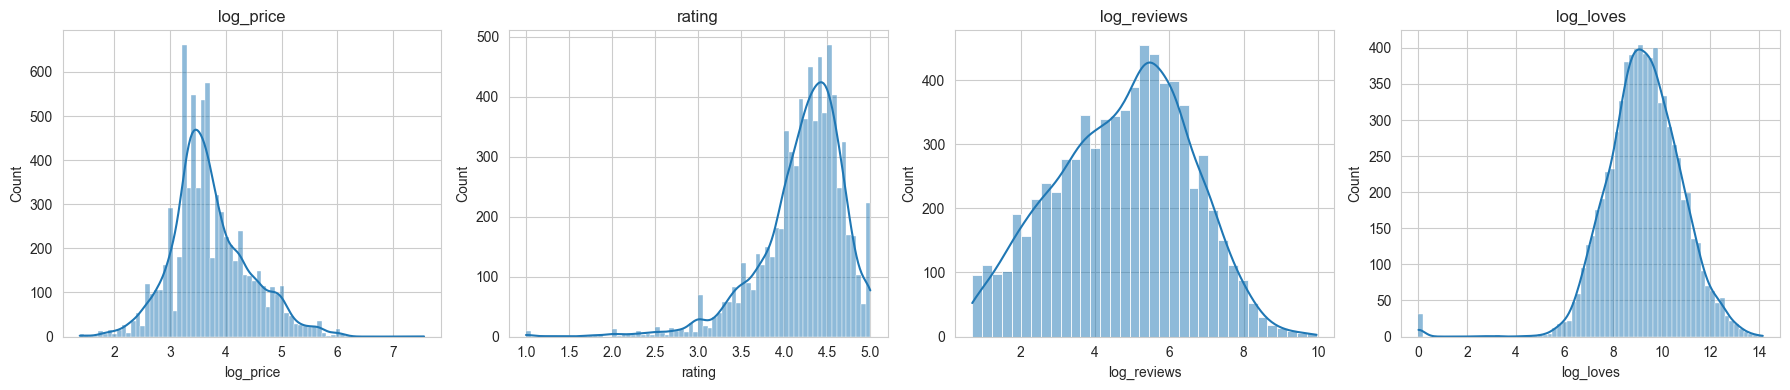

In [9]:
products_clean['log_price'] = np.log1p(products_clean['price_usd'])
products_clean['log_reviews'] = np.log1p(products_clean['reviews'])
products_clean['log_loves'] = np.log1p(products_clean['loves_count'])

model_feats = ['log_price', 'rating', 'log_reviews', 'log_loves']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, model_feats):
    sns.histplot(products_clean[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Scaling
Since KMeans relies on distance, I will use sklearn `StandardScaler` so each feature has mean=0, std=1.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(products_clean[model_feats])
X_scaled.shape

(7305, 4)

## TO BE CONTINUED...